In [1]:
from pathlib import Path

import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd()
with open(PROJECT_ROOT / "config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config["paths"]
preprocessing_config = config["preprocessing"]
random_seed = config["project"]["random_seed"]

In [2]:
# read data from csv file
df = pd.read_csv(PROJECT_ROOT / paths["raw_complaints"])

df.memory_usage(deep=True) >>>see usage of each col in df so here we will see the whole df usage


In [3]:

memory_gb = (
    df.memory_usage(deep=True)
    .sum()
    /
    1024**3
)

print(f"{memory_gb:.2f} GB")

4.48 GB


we see dist for product in df(not for issue as issue has high cardinality so will be harder for stratify)

In [4]:
product_dist = (
    df["Product"]
    .value_counts(normalize=True)
    *100
)

product_dist

Product
Credit reporting or other personal consumer reports                             70.668789
Debt collection                                                                  9.162829
Checking or savings account                                                      4.597021
Credit card                                                                      4.408811
Money transfer, virtual currency, or money service                               3.632455
Credit reporting, credit repair services, or other personal consumer reports     2.083084
Mortgage                                                                         1.580077
Vehicle loan or lease                                                            1.133236
Student loan                                                                     1.106971
Payday loan, title loan, personal loan, or advance loan                          0.732412
Prepaid card                                                                     0.416388
Cr

In [5]:
sample_random = df.sample(
    n=preprocessing_config["sample_size"],
    random_state=random_seed
)

In [6]:
original_product = (
    df["Product"]
    .value_counts(normalize=True)
    * 100
)

original_product

Product
Credit reporting or other personal consumer reports                             70.668789
Debt collection                                                                  9.162829
Checking or savings account                                                      4.597021
Credit card                                                                      4.408811
Money transfer, virtual currency, or money service                               3.632455
Credit reporting, credit repair services, or other personal consumer reports     2.083084
Mortgage                                                                         1.580077
Vehicle loan or lease                                                            1.133236
Student loan                                                                     1.106971
Payday loan, title loan, personal loan, or advance loan                          0.732412
Prepaid card                                                                     0.416388
Cr

In [7]:
sample_product = (
    sample_random["Product"]
    .value_counts(normalize=True)
    * 100
)

sample_product

Product
Credit reporting or other personal consumer reports                             70.670
Debt collection                                                                  9.314
Checking or savings account                                                      4.642
Credit card                                                                      4.328
Money transfer, virtual currency, or money service                               3.628
Credit reporting, credit repair services, or other personal consumer reports     2.074
Mortgage                                                                         1.560
Student loan                                                                     1.142
Vehicle loan or lease                                                            1.066
Payday loan, title loan, personal loan, or advance loan                          0.682
Prepaid card                                                                     0.440
Credit card or prepaid card        

In [8]:
comparison = pd.DataFrame({
    "Original %": original_product,
    "Sample %": sample_product
})

comparison

,Original %,Sample %
Product,,
Checking or savings account,4.597021,4.642
Credit card,4.408811,4.328
Credit card or prepaid card,0.231520,0.240
Credit reporting or other personal consumer reports,70.668789,70.670
"Credit reporting, credit repair services, or other personal consumer reports",2.083084,2.074
Debt collection,9.162829,9.314
Debt or credit management,0.222299,0.196
"Money transfer, virtual currency, or money service",3.632455,3.628
Mortgage,1.580077,1.560


as random sampling give us very well percentage for each product so we don`t need to make Stratified Sampling
because 50k is not small no
as Original Product distribution â‰ˆ Sample Product distribution

In [9]:
sample_random.shape

(50000, 16)

In [10]:
sample_random.shape

(50000, 16)

In [79]:
import re

def clean_cfpb_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Catch redacted dates FIRST, on the raw text (before any collapsing)
    text = re.sub(r'\b[Xx]{1,2}[/\-][Xx]{1,2}[/\-]\d{4}\b', '[DATE]', text)

    # 2. Anything else that's a run of 2+ X's -> generic redaction placeholder
    text = re.sub(r'\b[Xx]{2,}\b', '[PROTECTED]', text)

    # 3. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

sample_random["Consumer complaint narrative"] = (
    sample_random["Consumer complaint narrative"]
    .apply(clean_cfpb_text)
)

In [83]:
from lingua import Language, LanguageDetectorBuilder

languages = [
    Language.ENGLISH,
    Language.SPANISH,
    Language.FRENCH,
    Language.GERMAN,
    Language.CHINESE,
    Language.ARABIC,
]

detector = LanguageDetectorBuilder.from_languages(*languages).build()

In [89]:
text = sample_random.iloc[0]["Consumer complaint narrative"]

language = detector.detect_language_of("text")

print(language)

Language.ENGLISH


In [86]:
sample_random["language"] = (
    sample_random["Consumer complaint narrative"]
    .apply(detector.detect_language_of)
)

In [87]:
sample_random["language"].value_counts()

language
Language.ENGLISH    50000
Name: count, dtype: int64

In [82]:
sample_random.to_csv(
    PROJECT_ROOT / paths["sample_50k"],
    index=False
)

In [15]:
sample_random["word_count"] = (
    sample_random["Consumer complaint narrative"]
    .fillna("")
    .str.split()
    .str.len()
)

In [16]:
sample_random["Consumer complaint narrative"].isna().sum()

np.int64(0)

In [17]:
(sample_random["word_count"] == 0).sum()

np.int64(0)

In [18]:
sample_random["word_count"].describe()

count    50000.000000
mean       172.424980
std        220.721391
min          2.000000
25%         58.000000
50%        112.000000
75%        207.000000
max       5878.000000
Name: word_count, dtype: float64

Matplotlib is building the font cache; this may take a moment.


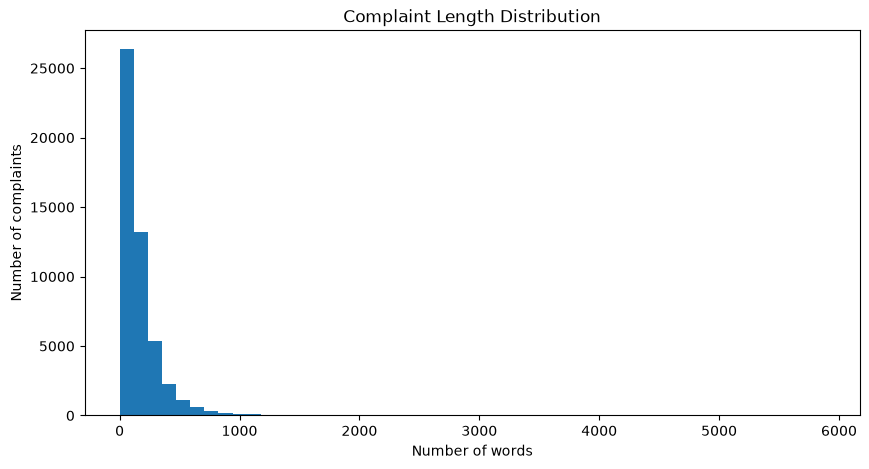

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    sample_random["word_count"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of complaints")
plt.title("Complaint Length Distribution")

plt.show()

In [90]:
sample_random["word_count"].quantile(
    [0.5,0.75,0.9,0.95,0.99]
)

0.50    112.00
0.75    207.00
0.90    355.00
0.95    497.00
0.99    992.01
Name: word_count, dtype: float64

In [91]:
short_texts = sample_random[
    sample_random["word_count"] < 5
]


as texts are too long(specially in the "Consumer complaint narrative" column), we will set the display option to show the full text in the dataframe


In [92]:
pd.set_option(
    "display.max_colwidth",
    None
)

In [93]:

short_texts[
    [
        "Consumer complaint narrative"
    ]
]

,Consumer complaint narrative
93758,See the attached documents.
108631,See document attached
546916,final demand to comply
571717,Incorrect reporting
492773,Please see attached file
187030,[DATE] [PROTECTED] NOT MINDS
171800,Delete Hard Inquiries ASAP
67367,See document attached
1497205,Incorrect information/ Non-compliant reporting
314026,They added late payments


In [94]:

len(short_texts[
    [
        "Consumer complaint narrative"
    ]
])

23

so i found only 23 rows less than 5 words,and my dataset is 50,000 rows
so Percentage: 23 / 50000 = 0.046%  This is nothing.
Removing them will not change your clustering,Therefore I would not spend time making rules for them now.

In [95]:
null_count = sample_random["Consumer complaint narrative"].isna().sum()

print(null_count)

0


so we will not remove any row as there is no nulls

now i will removes spaces at the beginning and end.


In [96]:
sample_random["Consumer complaint narrative"] = (
    sample_random["Consumer complaint narrative"]
    .str.strip()
)

now i will go to duplication and why there are alot of duplicated senteces in narrative


Reason 1: Template complaints: Many consumers submit complaints using templates.\
Reason 2: Companies/organizations help users submit complaints:Some organizations provide text templates.\
Reason 3: CFPB data contains standardized responses:Sometimes narratives are very similar because people describe the same type of issue.

In [97]:
sample_random["Consumer complaint narrative"].nunique()

35993

THIS means:50000 - 36630 = 13370 repeated rows which is large no and to check that there is 13370 duplicated see next line

In [98]:
print(sample_random["Consumer complaint narrative"].duplicated().sum())

14007


In [99]:
(
    sample_random["Consumer complaint narrative"]
    .value_counts()
    .head(20)
)

Consumer complaint narrative
In accordance with the Fair Credit Reporting act. The List of accounts below has violated my federally protected consumer rights to privacy and confidentiality under 15 USC 1681. 15 U.S.C 1681 section 602 A. States I have the right to privacy. 15 U.S.C 1681 Section 604 A Section 2 : It also states a consumer reporting agency can not furnish a account without my written instructions 15 U.S.C 1681c. ( a ) ( 5 ) Section States : no consumer reporting agency may make any consumer report containing any of the following items of information Any other adverse item of information, other than records of convictions of crimes which antedates the report by more than seven years. 15 U.S.C. 1681s-2 ( A ) ( 1 ) A person shall not furnish any information relating to a consumer to any consumer reporting agency if the person knows or has reasonable cause to believe that the information is inaccurate.                                                                           

why remove duplicates:\
my goal is BERTopic = discover topics\
not:Count popularity\
For topic discovery, duplicates can distort the clusters.\
as HDBSCAN may think:"This is a very dense region, this must be an important cluster."\
But it is important because of repetition, not because there are many different complaints.


In [100]:
bertopic_df = sample_random.drop_duplicates(
    subset=[preprocessing_config["deduplicate_column"]]
)

In [101]:
bertopic_df.shape

(35993, 18)

so i Keep original 50k as "sample_random"\
and Create a clean BERTopic dataset by removing exact duplicates "bertopic_df"\
so for "bertopic_df" i will use itt for embedding and later after assigning topic for each row\
i will use sample_random again for analsis "Put topics back on the original data" and it is usefull as if we need to count How many total customers have Topic 3? (So we use the original data.)

In [103]:
bertopic_df.to_csv(
    PROJECT_ROOT / paths["bertopic_ready"],
    index=False
)

In [104]:
bertopic_df.shape

(35993, 18)

In [105]:
bertopic_df

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,word_count,language
1923534,2025-09-18T02:30:29.000Z,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"To Whom It May Concern, I am writing in response to a received on regarding an alleged debt [PROTECTED] CREDIT CARD Collection you claim I owe. Please be advised that I am requesting validation of this debt, as is my right under the Fair Debt CREDIT CARD Collection Practices Act, 15 U.S.C. 1692g. Pursuant to this law, I respectfully request that you provide the following information : 1. The name and address of the original creditor. 2. A detailed statement of the alleged debt, including the amount and how it was calculated. 3. A copy of the original signed debt collection agreement or contract. 4. Proof that you are legally authorized to collect this debt. 5. A full accounting of payments, interest, fees, and charges applied to the alleged balance. 6. A copy of the judgment ( if any ) or other documents proving your legal right to collect this debt. Until you provide proper validation, I am requesting that all collection activity cease, including any reporting to the credit bureaus. If this debt is being reported to any credit reporting agency, be advised that failure to validate may constitute a violation of the Fair Credit Reporting Act ( FCRA ), and I will take appropriate steps to dispute the entry. This letter is sent in good faith and for the purpose of resolving any errors or misidentifications. Please respond to this request within 30 days from your receipt of this letter. regarding an alleged debt you claim I owe. Please be advised that this is not a refusal to pay, but a request for validation under the Fair Debt Collection Practices Act ( FDCPA ), 15 U.S.C. 1692g. Pursuant to my rights under the FDCPA, I request that you provide the following information : 1. The name and address of the original creditor 2. The amount of the alleged debt, including a breakdown of all fees and interest 3. A copy of the original agreement or contract bearing my signature look the same on my Id 4. Proof that you are authorized to collect this debt 5. A complete payment history, starting with the original creditor While awaiting verification, please : * Cease all collection activities, including phone calls, letters, or reporting to credit bureaus. * Do not contact me at my place of employment. * Do not contact any third parties about this debt. If you can not provide the requested verification, you must stop all collection efforts and remove any related information from my credit reports. Please respond to this request in writing. I recommend all future communication be done via mail only. Sincerely, [PROTECTED] [PROTECTED]",NaN,"EQUIFAX, INC.",NY,109XX,NaN,Web,2025-09-18T02:30:55.000Z,Closed with explanation,Yes,16011810.0,439,Language.ENGLISH
2049425,2026-03-13T00:27:38.000Z,Checking or savings account,Checking account,Problem with a lender or other company charging your account,Transaction was not authorized,"on Monday, [PROTECTED]/[PROTECTED]/[PROTECTED] of [PROTECTED] I sent a dispute to Cash app about four charges of the amount of {$83.00} that was taken out of my account on different dateson [PROTECTED]/[PROTECTED]/[PROTECTED] for some reason I was reimbursed three out of the four charges That I was disputing and I contacted Cash app about the reason for the denial on one of them and they wouldnt give me a proper reasoning and I sent them proof that the charges were being taken out with consents so now Im looking to see if I can get assistance in helping me retrieve that one charge that is missing The documents that I am submitting shows the proof that I submitted to Cash App showing that I was canceling doing bus

# Notebook 01 â€” CFPB Complaint Data Preprocessing

## Goal of This Notebook

The goal of this notebook is to prepare the CFPB Consumer Complaint dataset for BERTopic.

Main objectives:

1. Load the raw CFPB dataset.
2. Understand the dataset structure.
3. Perform Exploratory Data Analysis (EDA).
4. Select the text column used for clustering.
5. Analyze text length and quality.
6. Create a representative sample (50k rows).
7. Clean the text data.
8. Remove exact duplicates for topic modeling.
9. Save the final dataset ready for embedding.

---

# Project Data Flow

```
Raw CFPB Dataset
        |
        â†“
Load DataFrame
        |
        â†“
EDA
        |
        â†“
Select Consumer Complaint Narrative
        |
        â†“
Random Sampling (50k)
        |
        â†“
Text Cleaning
        |
        â†“
Remove Exact Duplicates
        |
        â†“
Save BERTopic Ready Dataset
        |
        â†“
Embedding Phase
```

---

# 1. Import Libraries
---

# 2. Load Dataset

load the whole dataset "complaints.csv"

## Why low_memory=False?

The dataset contains many columns with mixed data types.

Pandas normally reads the file in chunks and guesses column types.

`low_memory=False` tells pandas: "Read the whole file first, then decide the data types."
This avoids incorrect dtype warnings.

---

# 3. Basic Dataset Inspection

## Shape: df.shape

## Columns: df.columns
```

Used to understand available information.

Important columns:

* Consumer complaint narrative â†’ text used for clustering
* Product â†’ complaint category
* Issue â†’ complaint type
* Company â†’ company receiving complaint
* Date received â†’ used later for trend analysis


# 4. Select Important Columns

For BERTopic we mainly need:

```python
important_cols = [
    "Consumer complaint narrative",#used for embedding
    "Product", #used to stratify data in sampling
    "Issue", #we will evaluate out cluster based on it
    "Company", 
    "Date received"
]

df = df[important_cols]
```

Explanation:

### Consumer complaint narrative

The actual customer complaint text.

Example:

```
"My credit report contains inaccurate information."
```

This is the input for embeddings.

---

### Product

Used later for analysis.

Example:

```
Credit card
Mortgage
Debt collection
```

Not used for clustering.

---

### Issue

Existing CFPB category.

Used only for evaluation.

We do not give it to BERTopic.

---

### Company

Used later to analyze which companies receive which topics.

Not used for clustering.

---

### Date received

Used later for topic evolution/trends.

Not used for clustering.

---

# 5. Check Missing Values

```python
df.isnull().sum()
```

Important:

```python
Consumer complaint narrative
```

must not be empty because it is the text input.

---

Remove missing narratives:

```python
df = df.dropna(
    subset=["Consumer complaint narrative"]
)
```

---

# 6. Create 50k Sample

The full dataset is too large for local embedding.

Create a manageable sample:

```python
sample_random = df.sample(
    n=50000,
    random_state=42
)
```

Explanation:

* `n=50000` â†’ number of complaints
* `random_state=42` â†’ reproduce the same sample every time

---

# 7. Check Sampling Distribution

Before clustering, verify that the sample represents the original data.

Example Product distribution:

```python
df["Product"].value_counts(normalize=True) * 100
```

Compare with:

```python
sample_random["Product"].value_counts(normalize=True) * 100
```

`normalize=True` gives percentages instead of counts.

---

# 8. Analyze Text Length

Create word count:

```python
sample_random["word_count"] = (
    sample_random["Consumer complaint narrative"]
    .fillna("")
    .str.split()
    .str.len()
)
```

Explanation:

### fillna("")

Replace missing text with empty string.

### str.split()

Split sentence into words.

Example:

```
"My card was charged twice"
```

becomes:

```
["My","card","was","charged","twice"]
```

### str.len()

Counts the number of words.

---

Check statistics:

```python
sample_random["word_count"].describe()
```

Example:

```
count    50000
mean       172
50%        112
75%        207
max       5878
```

---

Check higher percentiles:

```python
sample_random["word_count"].quantile(
    [0.5,0.75,0.9,0.95,0.99]
)
```

Used to understand long documents.

---

# 9. Inspect Very Short Complaints

Example:

```python
sample_random[
    sample_random["word_count"] < 10
]["Consumer complaint narrative"]
```

Purpose:

Check if there are useless texts.
but i found that even short sentences are usefull

Examples:

```
See attached documents
Incorrect reporting
Delete inquiry ASAP
```

Decision:

Do not remove automatically because the number is small.

---

# 10. Basic Text Cleaning

Remove extra spaces:

```python
sample_random[
    "Consumer complaint narrative"
] = (
    sample_random[
        "Consumer complaint narrative"
    ]
    .str.strip()
)
```

Purpose:

Convert:

```
"   Wrong information on report   "
```

into:

```
"Wrong information on report"
```

---

# 11. Check Exact Duplicates

Count repeated texts:

```python
sample_random[
    "Consumer complaint narrative"
].duplicated().sum()
```

This counts only repeated copies after the first occurrence.

---

Show all duplicate groups:

```python
duplicates = sample_random[
    sample_random[
        "Consumer complaint narrative"
    ].duplicated(
        keep=False
    )
]
```

`keep=False` marks:

* original row
* repeated rows

as duplicates.

---

Find most repeated complaints:

```python
(
sample_random[
    "Consumer complaint narrative"
]
.value_counts()
.head(20)
)
```

Reason:

CFPB contains many template complaints.

---

# 12. Create BERTopic Dataset

Remove exact duplicates:

```python
bertopic_df = sample_random.drop_duplicates(
    subset=[
        "Consumer complaint narrative"
    ]
)
```

Why?

BERTopic should discover different complaint themes.

Repeated templates can dominate clustering.

---

Check size:

```python
bertopic_df.shape
```

---

# 13. Save Data

Save original sample:

```python
sample_random.to_csv(
    "data/processed/cfpb_sample_50k.csv",
    index=False
)
```

Save BERTopic data:

```python
bertopic_df.to_csv(
    "data/processed/cfpb_bertopic_ready.csv",
    index=False
)
```
i also used lingua to detect language to check that the whole dataset is english which choosing embedding model will depend on it
i also handled xxxx:Handling CFPB Redacted Tokens

The CFPB dataset anonymizes sensitive information using placeholder tokens such as:

XXXX â†’ names, account numbers, companies, addresses, etc.
XX/XX/2024 â†’ dates
{$1200.00} â†’ monetary amounts

Instead of removing these tokens, I replaced them with semantic placeholders to preserve the sentence structure while removing meaningless identifiers:

Original	Replaced with
XXXX	[PROTECTED]
XX/XX/2024	[DATE]
{$1200.00}	[AMOUNT]

Why?

Preserves the grammatical structure of the complaint.
Prevents tokens like XXXX from becoming dominant words or forming meaningless topics.
Keeps semantic information (e.g., "a protected entity", "a date", "an amount") that may still be useful for embeddings and topic modeling.

but there is something important : we need to remove this words when using c-TF-idf as word like protected will apear alot but it has no relation with cluster:Now BERTopic goes back to the original text to find representative words.

Imagine one cluster has

I contacted [PROTECTED] Bank...
[PROTECTED] reported...
Payment to [PROTECTED]

Then c-TF-IDF may produce

protected
bank
payment
account

The word protected appears in many complaints simply because you inserted it.

But does it describe the topic?

No.

It's just an anonymization marker.
Therefore

At the topic representation stage only, we tell BERTopic:

CountVectorizer(
    stop_words=[
        ...
        "protected",
        "date",
        "amount"
    ]
)

Now c-TF-IDF ignores them.

Instead of

protected
account
credit
fraud

you get

account
credit
fraud
identity

Much better.
---

# Final Output of Notebook

At the end we have:

## sample_random (cfpb_sample_50k)

Contains:

* 50k complaints
* duplicates included
* metadata preserved

Used later for:

* business analysis
* topic frequency
* company/product trends

## bertopic_df

Contains:

* unique complaint narratives
* ready for embeddings

Used for:

* embedding model
* BERTopic clustering
* topic discovery

---

# Next Notebook

## Notebook 02 â€” Embedding + BERTopic

Steps:

1. Load `cfpb_bertopic_ready.csv`
2. Generate embeddings
3. Apply BERTopic
4. Use HDBSCAN for clustering
5. Extract topic keywords
6. Generate topic names using LLM
7. Analyze topic trends


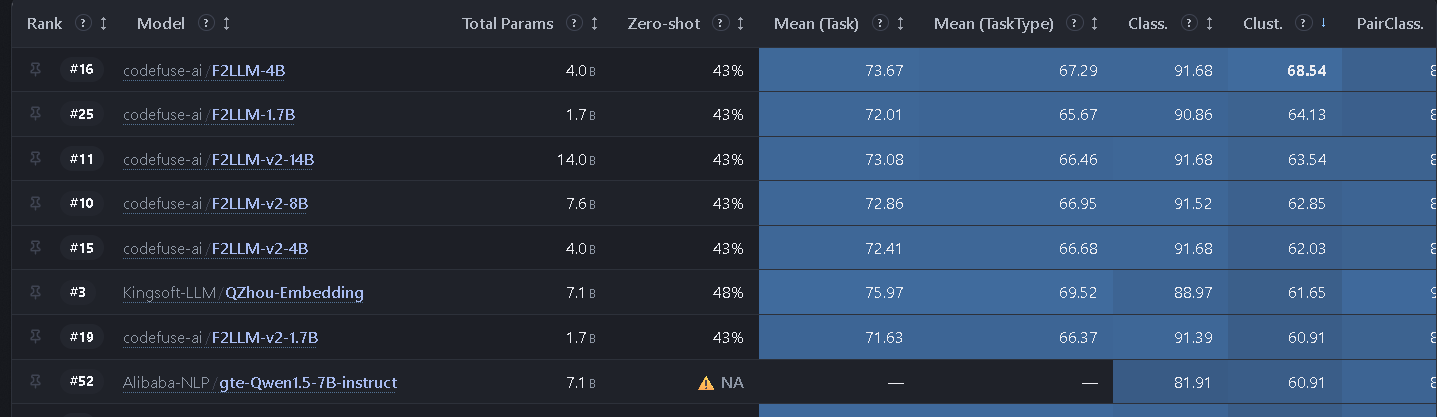

in https://huggingface.co/spaces/mteb/leaderboard
in MTEP
so this benchmark and i used rank#25 as it is no2 in clustering but faster than fist one rank#16 as it only 1.6B parameter but first one in clustering is 4B

Your project pipeline

You have already finished:

Notebook 1
â”‚
â”œâ”€â”€ Load CFPB data
â”œâ”€â”€ EDA
â”œâ”€â”€ Sample 50k
â”œâ”€â”€ Remove duplicates
â”œâ”€â”€ Save cfpb_bertopic_ready.csv   (~36k complaints)

Now comes Notebook 2.

Notebook 2
â”‚
â”œâ”€â”€ Load csv
â”œâ”€â”€ Load embedding model
â”œâ”€â”€ Generate embeddings
â”œâ”€â”€ Save embeddings.npy

Then everything else (BERTopic, UMAP, HDBSCAN, analysis) can be done locally.

Are the embeddings large?

Let's estimate.

You have approximately

36,000 documents

Embedding dimension

2048

Stored as float32

36000 Ã— 2048 Ã— 4 bytes
â‰ˆ 295 MB

That's not large. Around 300 MB is perfectly manageable.

I think this is the right point to switch to Colab. Your workflow now becomes:

Notebook 01 (Local)\
    â†“\
Load CFPB\
EDA
Sampling (50k)\
Cleaning\
Remove duplicates\
Save sample_random_clean.csv\
    â†“\
Notebook 02 (Colab)\
Load cleaned CSV\
Load embedding model\
Generate embeddings\
Save embeddings.npy\
Save cleaned CSV (same order)\
    â†“\
Notebook 03 (Local)\
Load CSV\
Load embeddings.npy\
UMAP\
HDBSCAN\
c-TF-IDF\
Analysis\
Visualization\